In this version, we allow duplicate triads to make creating $G$ easier.

# Old work

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)

In [6]:
%%time

k=[];p=[];q=[]

for i in range(len(idk.T)):
    tmp1=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)<=kmax) & (np.linalg.norm(idk,axis=0)<=kmax) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)<=kmax)
    tmp2=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)>=kmin) & (np.linalg.norm(idk,axis=0)>=kmin) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)>=kmin)
    if (tmp1&tmp2).sum()!=0:
        k.append(np.array([idk.T[i]]*(tmp1&tmp2).sum()))
        tmp=idk.T[tmp1&tmp2]
        p.append(tmp)
        q.append(-tmp-idk.T[i])

k=np.row_stack(k).T;p=np.row_stack(p).T;q=np.row_stack(q).T
kmag=np.linalg.norm(k,axis=0)
pmag=np.linalg.norm(p,axis=0)
qmag=np.linalg.norm(q,axis=0)

CPU times: user 930 ms, sys: 73.5 ms, total: 1 s
Wall time: 1 s


In [40]:
def plot_G(G,colorbar=False):
    fig,ax=plt.subplots(2,3,layout='constrained',figsize=(10,6))
    
    points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])]
    coords=(idk+kmax).astype(int)
    
    for i in range(len(points)):
        grid=np.zeros([n]*2)
        grid[coords[1],coords[0]]=G[order(points[i])]
        grid[grid==0]=None
        ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
        im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
        ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
        if colorbar:
            plt.colorbar(im)    
    plt.show()

In [42]:
path='./data/'
triads=np.loadtxt(path+'triads.txt')
k_data=triads[:,[0,1]].T
p_data=triads[:,[2,3]].T
q_data=-k_data-p_data

k_order=order(k_data).argsort();p_order=order(p_data).argsort();q_order=order(q_data).argsort()
k_data=k_data[:,k_order];p_data=p_data[:,p_order];q_data=q_data[:,q_order]

kmag_data=np.linalg.norm(k_data,axis=0);pmag_data=np.linalg.norm(p_data,axis=0);qmag_data=np.linalg.norm(q_data,axis=0)

rhok=np.load(path+'rhok.npy').astype(np.float64)[0,k_order];rhop=np.load(path+'rhop.npy').astype(np.float64)[0,p_order];rhoq=np.load(path+'rhoq.npy').astype(np.float64)[0,q_order]

all_mag=np.array([kmag_data,pmag_data,qmag_data]).flatten()
all_rho=np.array([rhok,rhop,rhoq]).flatten()

a = 1.657861386762042, b = -2.3439511091862633


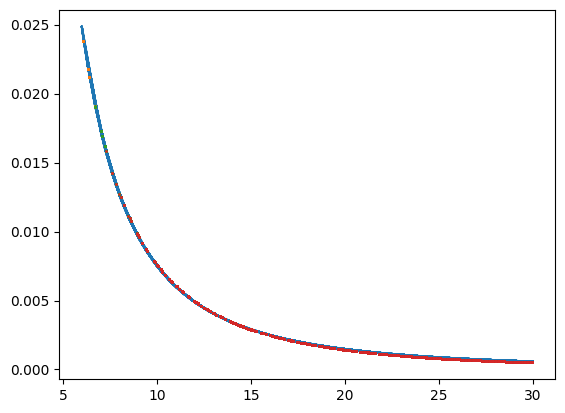

In [43]:
def rho(x,a,b):
    return a*(x**b)

a,b=curve_fit(rho,all_mag,all_rho)[0]
print(f'a = {a}, b = {b}')

plt.plot(kmag,rho(kmag,a,b))
plt.plot(kmag_data,rhok,'.',ms=1)
plt.plot(pmag_data,rhop,'.',ms=1)
plt.plot(qmag_data,rhoq,'.',ms=1)
plt.show()

# $\cos(\phi)$ term

In [46]:
K=np.zeros([len(idk.T)]*2)
K[order(k),order(p)]=((qmag**2-pmag**2)/kmag**2)*(rho(pmag,a,b)*rho(qmag,a,b))**2
K=K.sum(axis=1)[order(k)]
D=np.sqrt(pmag**2+qmag**2)
C=-np.cross(q,p,axis=0)/(rho(kmag,a,b)*rho(pmag,a,b)*rho(qmag,a,b))*K

In [47]:
G=np.zeros([len(idk.T)]*2)
G[order(k),order(p)]=(kmag**-2)*np.cross(q,p,axis=0)
Grho=np.zeros([len(idk.T)]*2)
Grho[order(k),order(p)]=(kmag**-2)*np.cross(q,p,axis=0) * rho(kmag,a,b)*rho(pmag,a,b)*rho(qmag,a,b)
Gcos=np.zeros([len(idk.T)]*2)
Gcos[order(k),order(p)]=(kmag**-2)*np.cross(q,p,axis=0) * -C/D
Gcosrho=np.zeros([len(idk.T)]*2)
Gcosrho[order(k),order(p)]=(kmag**-2)*np.cross(q,p,axis=0) * -C/D * rho(kmag,a,b)*rho(pmag,a,b)*rho(qmag,a,b)

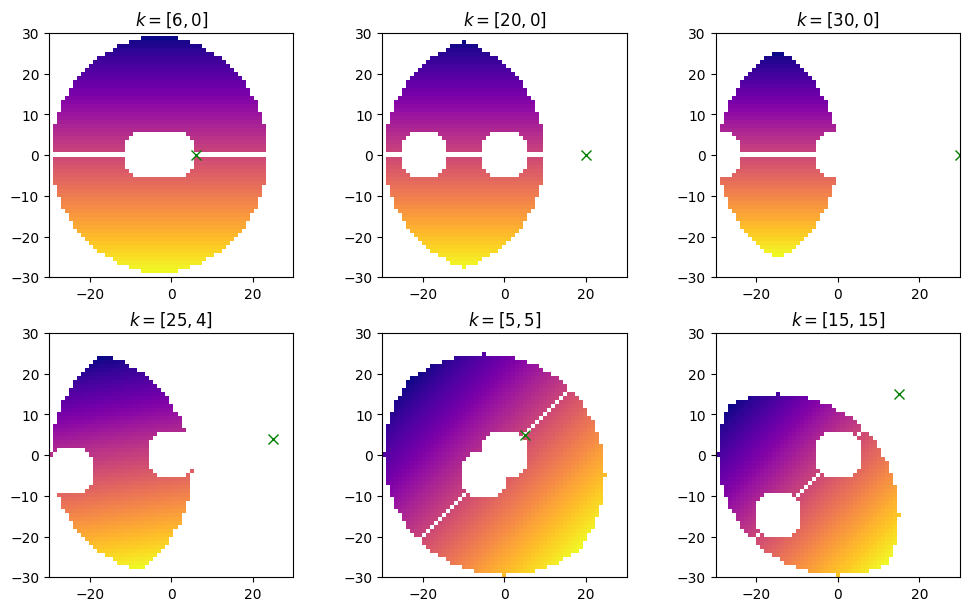

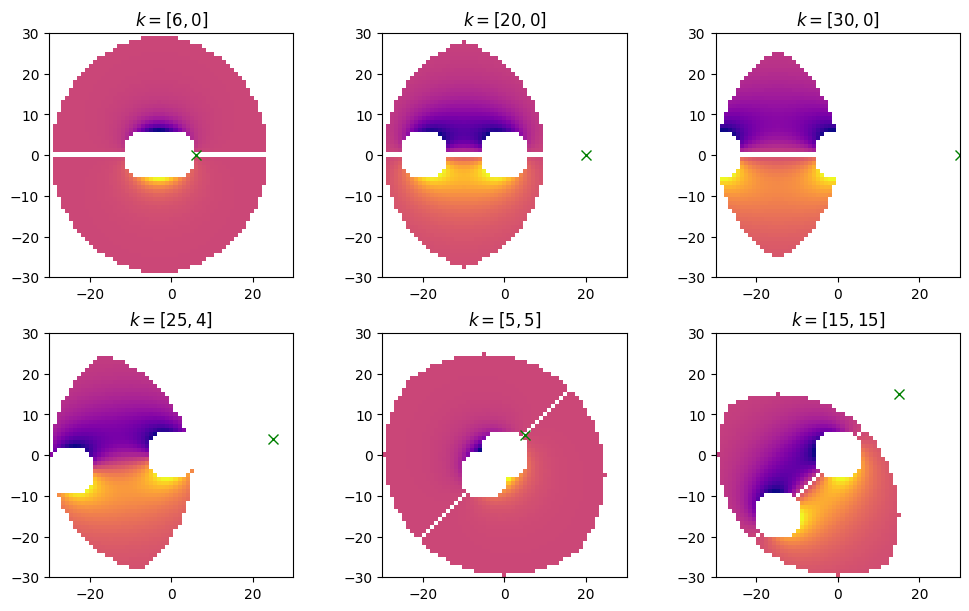

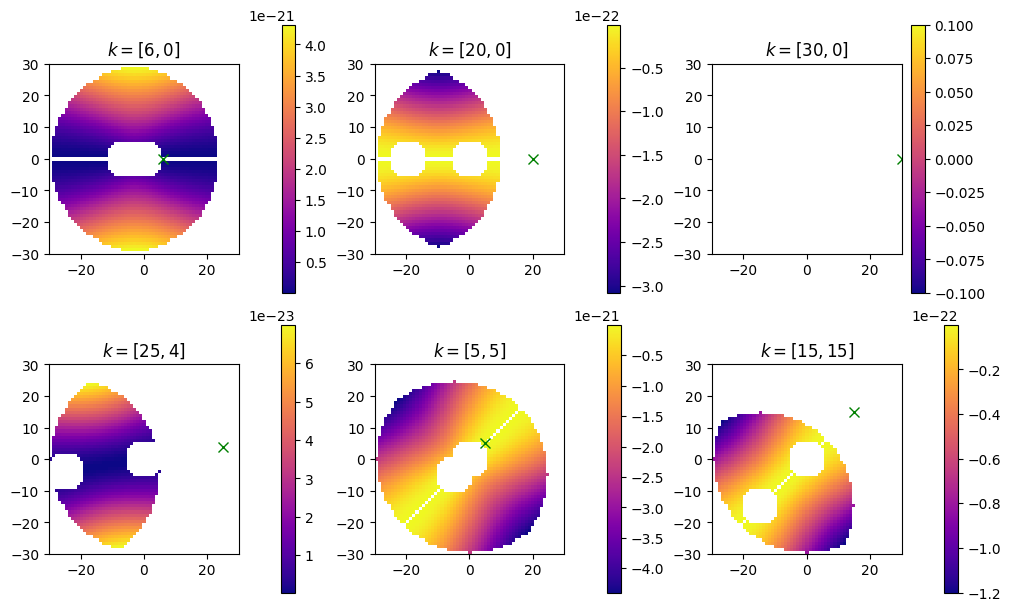

In [48]:
plot_G(G)
plot_G(Grho)
plot_G(Gcosrho,colorbar=True)